# CNN features for the quantum models

`hybrid_qml.ipynb` runs `image -> flatten 784 pixels -> PCA(4) -> scale -> 4-qubit model`.
This notebook replaces the front end with a small CNN and keeps everything after it
unchanged:

    image -> CNN -> 128-d features -> PCA(4) -> scale -> 4-qubit model


## 1. Setup

In [1]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pennylane as qml
import medmnist

from itertools import combinations
from medmnist import INFO
from sklearn.decomposition import PCA
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             roc_curve, confusion_matrix, classification_report)

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch device:", device)

torch device: cpu


In [2]:
import sys
import sklearn
import qiskit

print("python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("scikit-learn", sklearn.__version__)
print("pennylane   ", qml.__version__)
print("qiskit      ", qiskit.__version__)
print("torch       ", torch.__version__)
print("medmnist    ", medmnist.__version__)

python       3.14.4
numpy        2.4.4
scikit-learn 1.8.0
pennylane    0.45.1
qiskit       2.3.0
torch        2.13.0+cpu
medmnist     3.0.2


### 1.1 Data

The same fixed splits as before. Nothing is resplit or reshuffled.

In [3]:
data_flag = "pneumoniamnist"
info = INFO[data_flag]

PneumoniaData = getattr(medmnist, info["python_class"])

train_data = PneumoniaData(split="train", download=True)
val_data = PneumoniaData(split="val", download=True)
test_data = PneumoniaData(split="test", download=True)

x_train, y_train = train_data.imgs, train_data.labels.flatten()
x_val, y_val = val_data.imgs, val_data.labels.flatten()
x_test, y_test = test_data.imgs, test_data.labels.flatten()

print("Training:  ", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:      ", x_test.shape, y_test.shape)
print("Classes:", info["label"])

Training:   (4708, 28, 28) (4708,)
Validation: (524, 28, 28) (524,)
Test:       (624, 28, 28) (624,)
Classes: {'0': 'normal', '1': 'pneumonia'}


In [4]:
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    labels, counts = np.unique(y, return_counts=True)
    print(name, dict(zip(labels, counts)), " pneumonia fraction:", round(float(y.mean()), 3))

Train {np.uint8(0): np.int64(1214), np.uint8(1): np.int64(3494)}  pneumonia fraction: 0.742
Validation {np.uint8(0): np.int64(135), np.uint8(1): np.int64(389)}  pneumonia fraction: 0.742
Test {np.uint8(0): np.int64(234), np.uint8(1): np.int64(390)}  pneumonia fraction: 0.625


### 1.2 Two views of the same images

Divide by 255 and keep a flat `(N, 784)` view for the PCA arm and an `(N, 1, 28, 28)` view
for the CNN. No augmentation and no extra standardisation, so both arms see the same
pixels.

In [5]:
x_train_norm = x_train.astype("float64") / 255.0
x_val_norm = x_val.astype("float64") / 255.0
x_test_norm = x_test.astype("float64") / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_val_flat = x_val_norm.reshape(len(x_val_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

x_train_img = torch.tensor(x_train_norm, dtype=torch.float32).unsqueeze(1)
x_val_img = torch.tensor(x_val_norm, dtype=torch.float32).unsqueeze(1)
x_test_img = torch.tensor(x_test_norm, dtype=torch.float32).unsqueeze(1)

print("flat: ", x_train_flat.shape, x_val_flat.shape, x_test_flat.shape)
print("image:", tuple(x_train_img.shape), tuple(x_val_img.shape), tuple(x_test_img.shape))
print("Pixel range:", x_train_flat.min(), x_train_flat.max())

flat:  (4708, 784) (524, 784) (624, 784)
image: (4708, 1, 28, 28) (524, 1, 28, 28) (624, 1, 28, 28)
Pixel range: 0.0 1.0


### 2.1 The 100-image subset

A quantum kernel needs one circuit evaluation per pair of samples, so the models below use
the same balanced 100-image training subset as the original notebook. The draw is
reproduced exactly: same seed, same generator, same call order.

In [6]:
rng = np.random.default_rng(seed)

train_0 = rng.choice(np.where(y_train == 0)[0], 50, replace=False)
train_1 = rng.choice(np.where(y_train == 1)[0], 50, replace=False)

val_0 = rng.choice(np.where(y_val == 0)[0], 25, replace=False)
val_1 = rng.choice(np.where(y_val == 1)[0], 25, replace=False)

train_idx = np.concatenate([train_0, train_1])
val_idx = np.concatenate([val_0, val_1])

y_train_q = y_train[train_idx]
y_val_q = y_val[val_idx]

print("Train subset:", train_idx.shape, np.bincount(y_train_q))
print("Val subset:  ", val_idx.shape, np.bincount(y_val_q))
print("First five training indices:", train_idx[:5])

Train subset: (100,) [50 50]
Val subset:   (50,) [25 25]
First five training indices: [1782 2284 1992  426 3558]


### 2.2 Metrics

Same as the original notebook. Scores come from `decision_function` for the SVMs and from
the raw circuit expectation for the variational models, and the threshold is Youden's J on
the training scores only, then frozen.

In [7]:
def youden_threshold(y, scores):
    fpr, tpr, thr = roc_curve(y, scores)
    finite = np.isfinite(thr)
    return float(thr[finite][np.argmax((tpr - fpr)[finite])])


def auc_standard_error(y):
    n1, n0 = int((y == 1).sum()), int((y == 0).sum())
    return float(np.sqrt((n1 + n0 + 1) / (12.0 * n1 * n0)))


def metrics_at(y_true, scores, threshold):
    yhat = (scores >= threshold).astype(int)
    return {
        "AUC": round(roc_auc_score(y_true, scores), 4),
        "bal acc": round(balanced_accuracy_score(y_true, yhat), 4),
        "acc": round(accuracy_score(y_true, yhat), 4),
    }


se_val = auc_standard_error(y_val)
se_test = auc_standard_error(y_test)

print(f"AUC standard error: validation +/-{se_val:.4f}, test +/-{se_test:.4f}")
print(f"Differences smaller than about {2 * se_val:.2f} are not interpretable.")

AUC standard error: validation +/-0.0289, test +/-0.0239
Differences smaller than about 0.06 are not interpretable.


Models write their scores into these dictionaries, keyed by representation and model name.
Test scores are computed in the same pass as validation scores and set aside until section
8; nothing is selected after that point.

In [8]:
train_scores = {}
val_scores = {}
test_scores = {}
train_times = {}


def evaluate(name, y_true, scores):
    t = youden_threshold(y_train_q, train_scores[name])
    return metrics_at(y_true, scores[name], t)


def comparison_table(y_true, scores, label, with_time=False):
    table = []
    for name in scores:
        source, model = name.split(" | ")
        row = {"Feature source": source, "Reduction": "PCA-4", "Model": model}
        row.update({label + " " + k: v for k, v in evaluate(name, y_true, scores).items()})
        if with_time:
            row["fit (s)"] = train_times[name]
        table.append(row)
    return (pd.DataFrame(table)
            .sort_values(label + " AUC", ascending=False)
            .reset_index(drop=True))

## 3. Raw pixel features

The original front end, rebuilt here so the comparison arm comes from this run. PCA is fit
on the 4,708 training images only.

In [9]:
raw_pca = PCA(n_components=4, random_state=seed)
raw_pca.fit(x_train_flat)

raw_train_pca = raw_pca.transform(x_train_flat)
raw_val_pca = raw_pca.transform(x_val_flat)
raw_test_pca = raw_pca.transform(x_test_flat)

raw_scaler = MaxAbsScaler().fit(raw_train_pca)

raw_train_scaled = raw_scaler.transform(raw_train_pca)
raw_val_scaled = raw_scaler.transform(raw_val_pca)
raw_test_scaled = raw_scaler.transform(raw_test_pca)

print("Explained variance:", np.round(raw_pca.explained_variance_ratio_, 4))
print("Total:", round(float(raw_pca.explained_variance_ratio_.sum()), 4))
print("Shapes:", raw_train_scaled.shape, raw_val_scaled.shape, raw_test_scaled.shape)
print("Train range:", round(float(raw_train_scaled.min()), 3),
      round(float(raw_train_scaled.max()), 3))

Explained variance:

 [0.3787 0.0965 0.0701 0.0523]
Total: 0.5976
Shapes: (4708, 4) (524, 4) (624, 4)
Train range: -1.0 1.0


## 4. CNN feature extractor

### 4.1 Architecture

Three `Conv -> BatchNorm -> ReLU -> MaxPool` blocks at 16, 32 and 64 channels, then
`Linear(576, 128) -> ReLU -> Dropout -> Linear(128, 1)`. The 128-unit ReLU output is the
penultimate layer that section 4.4 extracts.

In [10]:
class ConfigCNN(nn.Module):
    def __init__(self, in_channels=1, channels=(16, 32, 64), dropout=0.3, fc_dim=128):
        super().__init__()
        layers = []
        c_in = in_channels

        for c_out in channels:
            layers += [nn.Conv2d(c_in, c_out, 3, padding=1),
                       nn.BatchNorm2d(c_out),
                       nn.ReLU(),
                       nn.MaxPool2d(2, 2)]
            c_in = c_out

        self.features = nn.Sequential(*layers)

        with torch.no_grad():
            flat_dim = self.features(torch.zeros(1, in_channels, 28, 28)).flatten(1).shape[1]

        self.embed = nn.Sequential(nn.Flatten(),
                                   nn.Dropout(dropout),
                                   nn.Linear(flat_dim, fc_dim),
                                   nn.ReLU())
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(fc_dim, 1))
        self.flat_dim = flat_dim
        self.fc_dim = fc_dim

    def embedding(self, x):
        return self.embed(self.features(x))

    def forward(self, x):
        return self.head(self.embedding(x)).squeeze(-1)


torch.manual_seed(seed)
cnn = ConfigCNN().to(device)

print(cnn)
print("\nConv output flattens to", cnn.flat_dim, "and the feature layer is", cnn.fc_dim, "wide")
print("Trainable parameters:", f"{sum(p.numel() for p in cnn.parameters()):,}")

ConfigCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (embed): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=5

### 4.2 Training

Trained on the full 4,708-image training split, not on the 100-image subset -- a
representation learner needs data, and the quantum models still see only the 100 images in
both arms.

Selection is on validation AUC, which is threshold-free and so unaffected by the 74/26
class imbalance, with the best checkpoint restored at the end. The test split is not used
here.

In [11]:
from torch.utils.data import TensorDataset, DataLoader

epochs, patience, batch_size, lr = 40, 8, 64, 1e-3

train_ds = TensorDataset(x_train_img, torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          generator=torch.Generator().manual_seed(seed))

optimizer = torch.optim.Adam(cnn.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss()

y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)


def evaluate_split(model, images, labels_t, labels):
    model.eval()
    with torch.no_grad():
        logits = model(images.to(device))
        loss = criterion(logits, labels_t).item()
        probs = torch.sigmoid(logits).cpu().numpy()
    return loss, accuracy_score(labels, (probs >= 0.5).astype(int)), roc_auc_score(labels, probs)

In [12]:
history = []
best_auc, best_epoch, best_state = -1.0, -1, None
start = time.time()

for epoch in range(1, epochs + 1):
    cnn.train()
    running, n = 0.0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(xb)
        n += len(xb)

    tr_loss, tr_acc, tr_auc = evaluate_split(cnn, x_train_img, y_train_t, y_train)
    va_loss, va_acc, va_auc = evaluate_split(cnn, x_val_img, y_val_t, y_val)

    history.append({"epoch": epoch, "train_loss": running / n, "eval_train_loss": tr_loss,
                    "val_loss": va_loss, "train_acc": tr_acc, "val_acc": va_acc,
                    "train_auc": tr_auc, "val_auc": va_auc})

    if va_auc > best_auc:
        best_auc, best_epoch = va_auc, epoch
        best_state = {k: v.detach().clone() for k, v in cnn.state_dict().items()}

    print(f"Epoch {epoch:2d}: train loss = {running / n:.4f}  val loss = {va_loss:.4f}  "
          f"train acc = {tr_acc:.4f}  val acc = {va_acc:.4f}  val AUC = {va_auc:.4f}"
          f"{'  <- best' if epoch == best_epoch else ''}", flush=True)

    if epoch - best_epoch >= patience:
        print(f"Early stop: no validation AUC gain for {patience} epochs")
        break

cnn.load_state_dict(best_state)
print(f"\nRestored epoch {best_epoch}, validation AUC {best_auc:.4f}, "
      f"{time.time() - start:.0f} seconds")

Epoch  1: train loss = 0.2044  val loss = 0.1139  train acc = 0.9582  val acc = 0.9561  val AUC = 0.9911  <- best


Epoch  2: train loss = 0.1134  val loss = 0.2085  train acc = 0.9191  val acc = 0.9122  val AUC = 0.9930  <- best


Epoch  3: train loss = 0.1034  val loss = 0.1890  train acc = 0.9312  val acc = 0.9275  val AUC = 0.9957  <- best


Epoch  4: train loss = 0.0868  val loss = 0.1212  train acc = 0.9639  val acc = 0.9618  val AUC = 0.9933


Epoch  5: train loss = 0.0787  val loss = 0.0888  train acc = 0.9737  val acc = 0.9676  val AUC = 0.9946


...

Epoch 11: train loss = 0.0408  val loss = 0.1124  train acc = 0.9788  val acc = 0.9523  val AUC = 0.9958


Epoch 12: train loss = 0.0351  val loss = 0.0709  train acc = 0.9970  val acc = 0.9733  val AUC = 0.9960


Epoch 13: train loss = 0.0451  val loss = 0.0889  train acc = 0.9883  val acc = 0.9676  val AUC = 0.9957


Epoch 14: train loss = 0.0301  val loss = 0.2085  train acc = 0.9535  val acc = 0.9408  val AUC = 0.9951


Early stop: no validation AUC gain for 8 epochs

Restored epoch 6, validation AUC 0.9969, 37 seconds


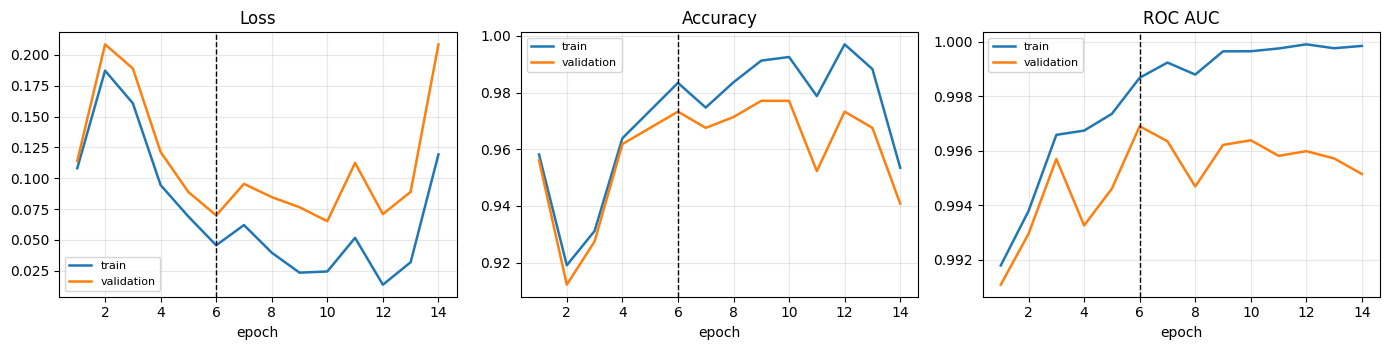

In [13]:
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

for ax, (a, b, title) in zip(axes, [("eval_train_loss", "val_loss", "Loss"),
                                    ("train_acc", "val_acc", "Accuracy"),
                                    ("train_auc", "val_auc", "ROC AUC")]):
    ax.plot(hist.epoch, hist[a], linewidth=1.8, label="train")
    ax.plot(hist.epoch, hist[b], linewidth=1.8, label="validation")
    ax.axvline(best_epoch, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4.3 The CNN on its own

Reported for reference. It trains on the whole split, so it is not a fair opponent for the
100-image models -- it is the ceiling the 128-d representation carries.

In [14]:
cnn.eval()

with torch.no_grad():
    cnn_train_logits = cnn(x_train_img.to(device)).cpu().numpy()
    cnn_val_logits = cnn(x_val_img.to(device)).cpu().numpy()
    cnn_test_logits = cnn(x_test_img.to(device)).cpu().numpy()

t_cnn = youden_threshold(y_train, cnn_train_logits)

print("Threshold from training scores:", round(t_cnn, 4))
print("Validation:", metrics_at(y_val, cnn_val_logits, t_cnn))
print("Test:      ", metrics_at(y_test, cnn_test_logits, t_cnn))

Threshold from training scores: 0.3458
Validation: {'AUC': 0.9969, 'bal acc': 0.971, 'acc': 0.9714}
Test:       {'AUC': 0.9599, 'bal acc': 0.844, 'acc': 0.8798}


### 4.4 Penultimate features

The classifier head is bypassed and the 128-d ReLU activation is kept. From here the CNN is
frozen and used only as a fixed function.

In [15]:
def extract_features(model, images, batch=256):
    model.eval()
    out = []

    with torch.no_grad():
        for i in range(0, len(images), batch):
            out.append(model.embedding(images[i:i + batch].to(device)).cpu().numpy())

    return np.concatenate(out).astype("float64")


train_cnn_features = extract_features(cnn, x_train_img)
val_cnn_features = extract_features(cnn, x_val_img)
test_cnn_features = extract_features(cnn, x_test_img)

print("train CNN features:", train_cnn_features.shape)
print("val CNN features:  ", val_cnn_features.shape)
print("test CNN features: ", test_cnn_features.shape)

train CNN features: (4708, 128)
val CNN features:   (524, 128)
test CNN features:  (624, 128)


## 5. What the features look like

A ReLU embedding is non-negative and usually sparse, which matters because PCA and
`MaxAbsScaler` behave differently on that than on roughly symmetric pixel components.

In [16]:
for name, F in [("train", train_cnn_features), ("val", val_cnn_features),
                ("test", test_cnn_features)]:
    print(f"{name:5s} {str(F.shape):12s} mean {F.mean():7.4f}  std {F.std():7.4f}  "
          f"min {F.min():7.4f}  max {F.max():8.4f}  zeros {100 * (F == 0).mean():5.1f}%  "
          f"NaN {int(np.isnan(F).sum())}  Inf {int(np.isinf(F).sum())}")

print("\nUnits never activated on the training split:",
      int((train_cnn_features.max(axis=0) == 0).sum()), "of", train_cnn_features.shape[1])

train (4708, 128)  mean  1.0893  std  1.5336  min  0.0000  max   8.4606  zeros  53.1%  NaN 0  Inf 0
val   (524, 128)   mean  1.0652  std  1.5000  min  0.0000  max   8.2776  zeros  52.6%  NaN 0  Inf 0
test  (624, 128)   mean  1.0260  std  1.4561  min  0.0000  max   8.2767  zeros  51.4%  NaN 0  Inf 0

Units never activated on the training split: 32 of 128


In [17]:
normal = train_cnn_features[y_train == 0]
pneumonia = train_cnn_features[y_train == 1]

print("normal    n =", len(normal), " mean", round(float(normal.mean()), 4),
      " std", round(float(normal.std()), 4))
print("pneumonia n =", len(pneumonia), " mean", round(float(pneumonia.mean()), 4),
      " std", round(float(pneumonia.std()), 4))

sep = np.abs(normal.mean(axis=0) - pneumonia.mean(axis=0)) / (train_cnn_features.std(axis=0) + 1e-12)
order = np.argsort(-sep)

print("\nPer-unit standardised class separation: max", round(float(sep[order[0]]), 3),
      " median", round(float(np.median(sep)), 3))
print("Five most discriminative units:", order[:5], np.round(sep[order[:5]], 3))

normal    n = 1214  mean 0.8443  std 1.3444
pneumonia n = 3494  mean 1.1745  std 1.5852

Per-unit standardised class separation: max 2.119  median 1.832
Five most discriminative units: [114 102 105  38   3] [2.119 2.116 2.111 2.098 2.098]


A 2D projection for inspection. Nothing computed here feeds the pipeline.

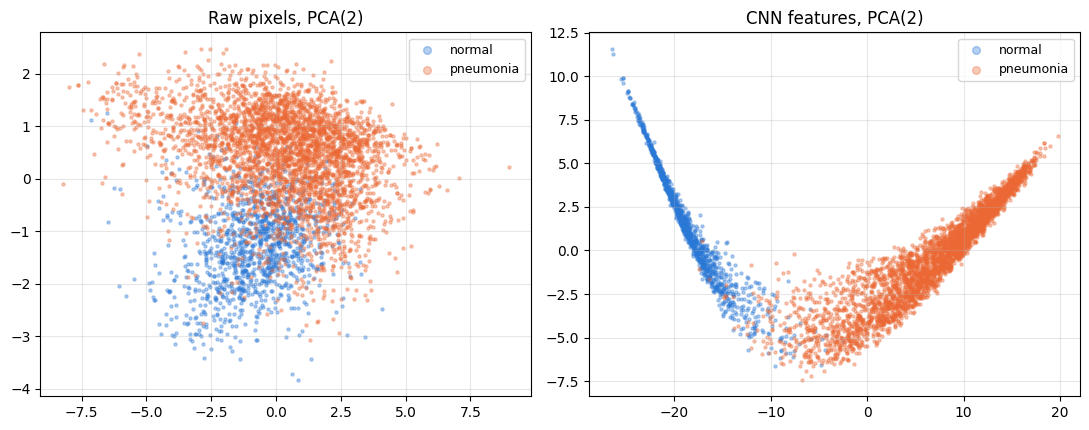

In [18]:
viz_raw = PCA(n_components=2, random_state=seed).fit_transform(x_train_flat)
viz_cnn = PCA(n_components=2, random_state=seed).fit_transform(train_cnn_features)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

for ax, Z, title in [(axes[0], viz_raw, "Raw pixels, PCA(2)"),
                     (axes[1], viz_cnn, "CNN features, PCA(2)")]:
    for label, colour in [(0, "#2a78d6"), (1, "#eb6834")]:
        m = y_train == label
        ax.scatter(Z[m, 0], Z[m, 1], s=5, alpha=0.35, c=colour, label=info["label"][str(label)])
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(markerscale=2.5, fontsize=9)

plt.tight_layout()
plt.show()

## 6. PCA and scaling on the CNN features

The same reduction the raw arm gets: PCA to 4 components and `MaxAbsScaler` into
`[-1, 1]`, both fit on training features only. Four components because the models have four
qubits.

In [19]:
cnn_pca = PCA(n_components=4, random_state=seed)
cnn_pca.fit(train_cnn_features)

cnn_train_pca = cnn_pca.transform(train_cnn_features)
cnn_val_pca = cnn_pca.transform(val_cnn_features)
cnn_test_pca = cnn_pca.transform(test_cnn_features)

print("Explained variance:", np.round(cnn_pca.explained_variance_ratio_, 4))
print("Cumulative:", np.round(np.cumsum(cnn_pca.explained_variance_ratio_), 4))
print("Shapes:", cnn_train_pca.shape, cnn_val_pca.shape, cnn_test_pca.shape)

full_pca = PCA(random_state=seed).fit(train_cnn_features)
for k in [2, 4, 8, 16]:
    print(k, "components:", round(float(full_pca.explained_variance_ratio_[:k].sum()), 4))

Explained variance: [0.9011 0.0537 0.0128 0.0062]
Cumulative: [0.9011 0.9547 0.9675 0.9737]
Shapes: (4708, 4) (524, 4) (624, 4)


2 components: 0.9547
4 components: 0.9737
8 components: 0.9817
16 components: 0.9885


These percentages are not comparable across arms. On raw pixels it is a fraction of pixel
variance; here it is a fraction of variance in a representation the network already shaped,
so a high number means the embedding is low-rank, not that more image information survived.

In [20]:
cnn_scaler = MaxAbsScaler().fit(cnn_train_pca)

cnn_train_scaled = cnn_scaler.transform(cnn_train_pca)
cnn_val_scaled = cnn_scaler.transform(cnn_val_pca)
cnn_test_scaled = cnn_scaler.transform(cnn_test_pca)

for name, A in [("Train", cnn_train_scaled), ("Val  ", cnn_val_scaled), ("Test ", cnn_test_scaled)]:
    print(f"{name} range: {A.min():7.4f} to {A.max():7.4f}   mean |x| {np.abs(A).mean():.4f}")

print("\nMean |feature| on the 100-image subset")
print("  raw pixels:  ", round(float(np.abs(raw_train_scaled[train_idx]).mean()), 4))
print("  CNN features:", round(float(np.abs(cnn_train_scaled[train_idx]).mean()), 4))

Train range: -1.0000 to  1.0000   mean |x| 0.2771
Val   range: -0.9481 to  1.0304   mean |x| 0.2745
Test  range: -0.9916 to  0.9514   mean |x| 0.2657

Mean |feature| on the 100-image subset
  raw pixels:   0.2027
  CNN features: 0.2665


In [21]:
representations = [
    ("Raw pixels", raw_train_scaled, raw_val_scaled, raw_test_scaled),
    ("CNN features", cnn_train_scaled, cnn_val_scaled, cnn_test_scaled),
]

for name, tr, va, te in representations:
    print(f"{name:13s} train {tr.shape}  val {va.shape}  test {te.shape}")

Raw pixels    train (4708, 4)  val (524, 4)  test (624, 4)
CNN features  train (4708, 4)  val (524, 4)  test (624, 4)


## 7. The models

Circuits, depths, optimiser settings and seeds are taken unchanged from `hybrid_qml.ipynb`.
The one adaptation is that functions which read globals there take arguments here, because
each now runs twice.

Two models from the original are left out. The book's `CZ` version of the ZZ map is a known
bug -- `CZ` is diagonal and `CZ . CZ = I`, so it encodes a product state -- and the PCA-8
hybrid has no counterpart because this arm is fixed at four components.

### 7.1 Quantum kernels

The kernel entry is the fidelity between two encoded states: run the feature map on `a`,
its adjoint on `b`, read the probability of measuring all zeros.

PennyLane broadcasts over the leading axis, so a whole kernel block goes in one call instead
of a Python double loop. Section 7.2 checks that this is exactly the same number.

In [22]:
nqubits = 4
dev = qml.device("default.qubit", wires=nqubits)


def ZZFeatureMap_cnot(data, nq=nqubits):
    for i in range(nq):
        qml.Hadamard(i)
        qml.RZ(2.0 * data[..., i], wires=i)

    for q0, q1 in combinations(range(nq), 2):
        qml.CNOT(wires=[q0, q1])
        qml.RZ(2.0 * (np.pi - data[..., q0]) * (np.pi - data[..., q1]), wires=q1)
        qml.CNOT(wires=[q0, q1])


@qml.qnode(dev)
def angle_kernel_circ(a, b):
    qml.AngleEmbedding(a, wires=range(nqubits))
    qml.adjoint(qml.AngleEmbedding)(b, wires=range(nqubits))
    return qml.probs(wires=range(nqubits))


@qml.qnode(dev)
def zz_kernel_circ(a, b):
    ZZFeatureMap_cnot(a)
    qml.adjoint(ZZFeatureMap_cnot)(b)
    return qml.probs(wires=range(nqubits))


def batched_kernel(circ, A, B, chunk=25000):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    ia, ib = np.meshgrid(np.arange(len(A)), np.arange(len(B)), indexing="ij")
    ia, ib = ia.ravel(), ib.ravel()
    out = np.empty(len(ia))

    for s in range(0, len(ia), chunk):
        block = slice(s, s + chunk)
        out[block] = np.asarray(circ(A[ia[block]], B[ib[block]]))[:, 0]

    return out.reshape(len(A), len(B))


def angle_qkernel(A, B):
    return batched_kernel(angle_kernel_circ, A, B)


def zz_qkernel(A, B):
    return batched_kernel(zz_kernel_circ, A, B)


probe = raw_train_scaled[train_idx][:2]
print("Self-fidelity:", round(float(angle_qkernel(probe[:1], probe[:1])[0, 0]), 12))
print("Two different samples:", round(float(angle_qkernel(probe[:1], probe[1:2])[0, 0]), 6))

Self-fidelity: 1.0
Two different samples: 0.795329


### 7.2 Is the batched kernel the same model?

The original builds its kernels with a nested loop. Batching is an implementation change, so
it has to be shown equal rather than assumed.

In [23]:
block_a = raw_train_scaled[train_idx][:8]
block_b = raw_train_scaled[train_idx][8:14]

for label, circ, batched in [("angle", angle_kernel_circ, angle_qkernel),
                             ("zz-cnot", zz_kernel_circ, zz_qkernel)]:
    looped = np.array([[circ(a, b)[0] for b in block_b] for a in block_a])
    print(f"{label:8s} max |loop - batched| = {np.abs(looped - batched(block_a, block_b)).max():.3e}")

angle    max |loop - batched| = 0.000e+00


zz-cnot  max |loop - batched| = 0.000e+00


### 7.3 Variational classifier

The corrected circuit from the original: `TwoLocal` with a closed entangling ring, the
`|0><0|` observable, `BCELoss` on 0/1 labels, angles scaled by `pi`, Adam at lr 0.05 for 60
epochs, `reps = 2`. Nothing is retuned for the new features.

In [24]:
ANGLE_SCALE = np.pi
VQC_REPS = 2
INIT_SEEDS = [42, 0, 1, 2, 3]

state_0 = [[1], [0]]
M = state_0 * np.conj(state_0).T

dev_vqc = qml.device("default.qubit", wires=nqubits)


def TwoLocalRing(nq, theta, reps=1):
    par = 0

    for r in range(reps):
        for q in range(nq):
            qml.RY(theta[par], wires=q)
            par += 1

        for q in range(nq - 1):
            qml.CNOT(wires=[q, q + 1])
        qml.CNOT(wires=[nq - 1, 0])

    for q in range(nq):
        qml.RY(theta[par], wires=q)
        par += 1


def make_vqc(reps):
    def circuit(inputs, theta):
        qml.AngleEmbedding(inputs, wires=range(nqubits))
        TwoLocalRing(nqubits, theta, reps=reps)
        return qml.expval(qml.Hermitian(M, wires=[0]))

    return qml.QNode(circuit, dev_vqc, interface="torch")


def train_vqc(x_tr, y_tr, reps=VQC_REPS, init_seed=seed, epochs=60, lr=0.05):
    circ = make_vqc(reps)
    nw = (reps + 1) * nqubits

    torch.manual_seed(init_seed)
    w = torch.nn.Parameter(2 * np.pi * torch.rand(nw, dtype=torch.float64))
    opt = torch.optim.Adam([w], lr=lr)
    bce = torch.nn.BCELoss()

    X = torch.tensor(x_tr * ANGLE_SCALE, dtype=torch.float64)
    Y = torch.tensor(y_tr.astype(np.float64), dtype=torch.float64)

    dead = None
    for epoch in range(epochs):
        opt.zero_grad()
        out = circ(X, w)
        loss = bce(torch.clamp(out, 1e-7, 1 - 1e-7), Y)
        loss.backward()
        if dead is None:
            dead = int((w.grad.abs() < 1e-8).sum())
        opt.step()

    return {"circ": circ, "weights": w.detach(), "params": nw, "dead": dead,
            "loss": loss.item()}


def score_vqc(fit, X):
    with torch.no_grad():
        return fit["circ"](torch.tensor(X * ANGLE_SCALE, dtype=torch.float64),
                           fit["weights"]).numpy()

### 7.4 Running both arms

One block, called twice. The SVMs are fit on the 100 images, then scored on the full
training subset, the 524-image validation split and the 624-image test split in one pass.

In [25]:
def run_representation(source, x_tr_full, x_va, x_te):
    x_tr = x_tr_full[train_idx]
    print(f"=== {source} ===  train {x_tr.shape}", flush=True)

    svm_rbf = SVC(kernel="rbf")
    start = time.time()
    svm_rbf.fit(x_tr, y_train_q)
    rbf_time = time.time() - start

    models = [("RBF SVM", svm_rbf, rbf_time)]

    for model_name, kernel in [("PennyLane Angle QSVM", angle_qkernel),
                               ("PennyLane ZZ QSVM (CNOT)", zz_qkernel)]:
        qsvm = SVC(kernel=kernel)
        start = time.time()
        qsvm.fit(x_tr, y_train_q)
        models.append((model_name, qsvm, time.time() - start))

    for model_name, model, secs in models:
        name = f"{source} | {model_name}"
        start = time.time()
        train_scores[name] = model.decision_function(x_tr)
        val_scores[name] = model.decision_function(x_va)
        test_scores[name] = model.decision_function(x_te)
        train_times[name] = round(secs, 4)
        print(f"  {model_name:26s} fit {secs:8.4f} s   scored {time.time() - start:5.1f} s",
              flush=True)

    name = f"{source} | PennyLane VQC"
    start = time.time()
    fit = train_vqc(x_tr, y_train_q)
    train_scores[name] = score_vqc(fit, x_tr)
    val_scores[name] = score_vqc(fit, x_va)
    test_scores[name] = score_vqc(fit, x_te)
    train_times[name] = round(time.time() - start, 4)
    print(f"  {'PennyLane VQC':26s} fit {train_times[name]:8.4f} s   "
          f"{fit['params']} params, {fit['dead']} dead", flush=True)


for source, tr, va, te in representations:
    run_representation(source, tr, va, te)

=== Raw pixels ===  train (100, 4)


  RBF SVM                    fit   0.0013 s   scored   0.0 s


  PennyLane Angle QSVM       fit   0.0644 s   scored   0.8 s


  PennyLane ZZ QSVM (CNOT)   fit   0.2957 s   scored   3.7 s


  PennyLane VQC              fit   0.9208 s   12 params, 3 dead


=== CNN features ===  train (100, 4)


  RBF SVM                    fit   0.0010 s   scored   0.0 s


  PennyLane Angle QSVM       fit   0.0610 s   scored   0.8 s


  PennyLane ZZ QSVM (CNOT)   fit   0.3074 s   scored   3.7 s


  PennyLane VQC              fit   0.8951 s   12 params, 3 dead


### 7.5 Qiskit

Qiskit's `zz_feature_map` conjugates its pair term with `CX`, which is what the PennyLane
`CNOT` map reproduces. Running it on both arms confirms the two frameworks still agree on
the new representation. This is the slowest cell here -- its fidelity kernel is evaluated
pair by pair rather than broadcast.

In [26]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

qiskit_feature_map = zz_feature_map(feature_dimension=4, reps=1)

print(qiskit_feature_map.decompose().draw("text"))

   ┌────────────┐┌───────────────┐                                         »
0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■──────────────────────────────────────»
   ├────────────┤├───────────────┤┌─┴─┐┌──────────────────────────────────┐»
1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├»
   ├────────────┤├───────────────┤└───┘└──────────────────────────────────┘»
2: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[2]) ├─────────────────────────────────────────»
   ├────────────┤├───────────────┤                                         »
3: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[3]) ├─────────────────────────────────────────»
   └────────────┘└───────────────┘                                         »
«                                                                »
«0: ──■────■────────────────────────────────────────■─────────■──»
«   ┌─┴─┐  │                                        │         │  »
«1: ┤ X ├──┼────────────────────────────────────────┼────■────┼──»
«   └───┘┌─┴─┐┌────────────────────────

In [27]:
for source, x_tr_full, x_va, x_te in representations:
    x_tr = x_tr_full[train_idx]
    name = f"{source} | Qiskit ZZ QSVM"

    qiskit_kernel = FidelityQuantumKernel(feature_map=qiskit_feature_map)
    qiskit_qsvc = QSVC(quantum_kernel=qiskit_kernel)

    start = time.time()
    qiskit_qsvc.fit(x_tr, y_train_q)
    qiskit_time = time.time() - start

    train_scores[name] = qiskit_qsvc.decision_function(x_tr)
    val_scores[name] = qiskit_qsvc.decision_function(x_va)
    test_scores[name] = qiskit_qsvc.decision_function(x_te)
    train_times[name] = round(qiskit_time, 4)

    print(f"{source:13s} fit {qiskit_time:6.1f} s   total {time.time() - start:6.1f} s",
          flush=True)

Raw pixels    fit   31.5 s   total  402.9 s


CNN features  fit   13.1 s   total  347.3 s


In [28]:
for source, _, _, _ in representations:
    a = val_scores[f"{source} | PennyLane ZZ QSVM (CNOT)"]
    b = val_scores[f"{source} | Qiskit ZZ QSVM"]
    print(f"{source:13s} max |difference| {np.abs(a - b).max():.3e}   "
          f"correlation {np.corrcoef(a, b)[0, 1]:.10f}   "
          f"AUC {roc_auc_score(y_val, a):.10f} vs {roc_auc_score(y_val, b):.10f}")

Raw pixels    max |difference| 4.853e-09   correlation 1.0000000000   AUC 0.9073978863 vs 0.9073978863
CNN features  max |difference| 2.094e-11   correlation 1.0000000000   AUC 0.9897362658 vs 0.9897362658


## 8. Evaluation

Thresholds come from each model's own training scores and are applied unchanged to
validation and test.

In [29]:
validation = comparison_table(y_val, val_scores, "val", with_time=True)

print(f"524-image validation split, AUC standard error +/-{se_val:.4f}")
validation

524-image validation split, AUC standard error +/-0.0289


,Feature source,Reduction,Model,val AUC,val bal acc,val acc,fit (s)
0,CNN features,PCA-4,PennyLane Angle QSVM,0.9963,0.9698,0.9695,0.0610
1,CNN features,PCA-4,RBF SVM,0.9935,0.9242,0.8874,0.0010
2,CNN features,PCA-4,Qiskit ZZ QSVM,0.9897,0.7584,0.6412,13.1489
3,CNN features,PCA-4,PennyLane ZZ QSVM (CNOT),0.9897,0.7584,0.6412,0.3074
4,Raw pixels,PCA-4,RBF SVM,0.9683,0.8772,0.8321,0.0013
5,Raw pixels,PCA-4,PennyLane Angle QSVM,0.9618,0.8672,0.8244,0.0644
6,CNN features,PCA-4,PennyLane VQC,0.9583,0.8824,0.8721,0.8951
7,Raw pixels,PCA-4,PennyLane ZZ QSVM (CNOT),0.9074,0.7905,0.8397,0.2957
8,Raw pixels,PCA-4,Qiskit ZZ QSVM,0.9074,0.7905,0.8397,31.5318
9,Raw pixels,PCA-4,PennyLane VQC,0.7429,0.6662,0.6336,0.9208


### 8.1 Test split

Scored once, after everything above was decided.

In [30]:
test = comparison_table(y_test, test_scores, "test")

print(f"624-image test split, AUC standard error +/-{se_test:.4f}")
test

624-image test split, AUC standard error +/-0.0239


,Feature source,Reduction,Model,test AUC,test bal acc,test acc
0,CNN features,PCA-4,PennyLane Angle QSVM,0.9623,0.8487,0.8814
1,CNN features,PCA-4,RBF SVM,0.9495,0.8962,0.9022
2,CNN features,PCA-4,Qiskit ZZ QSVM,0.9435,0.7799,0.7356
3,CNN features,PCA-4,PennyLane ZZ QSVM (CNOT),0.9435,0.7799,0.7356
4,Raw pixels,PCA-4,PennyLane Angle QSVM,0.9147,0.8299,0.8173
5,Raw pixels,PCA-4,RBF SVM,0.8988,0.8145,0.8013
6,Raw pixels,PCA-4,Qiskit ZZ QSVM,0.8459,0.7252,0.7612
7,Raw pixels,PCA-4,PennyLane ZZ QSVM (CNOT),0.8459,0.7252,0.7612
8,CNN features,PCA-4,PennyLane VQC,0.7049,0.6577,0.7035
9,Raw pixels,PCA-4,PennyLane VQC,0.6290,0.5923,0.5929


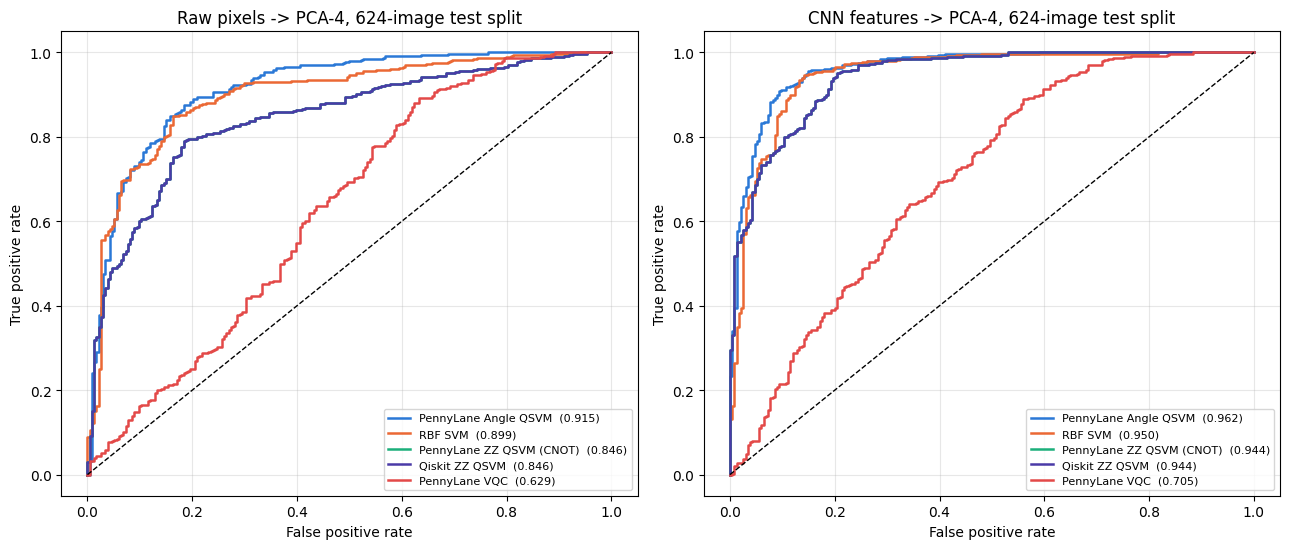

In [31]:
palette = {"RBF SVM": "#eb6834", "PennyLane Angle QSVM": "#2a78d6",
           "PennyLane ZZ QSVM (CNOT)": "#1baf7a", "Qiskit ZZ QSVM": "#4a3aa7",
           "PennyLane VQC": "#e34948"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

for ax, (source, _, _, _) in zip(axes, representations):
    names = [n for n in test_scores if n.startswith(source + " |")]

    for name in sorted(names, key=lambda n: -roc_auc_score(y_test, test_scores[n])):
        model = name.split(" | ")[1]
        fpr, tpr, _ = roc_curve(y_test, test_scores[name])
        ax.plot(fpr, tpr, linewidth=1.8, color=palette[model],
                label=f"{model}  ({roc_auc_score(y_test, test_scores[name]):.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    ax.set_title(f"{source} -> PCA-4, 624-image test split")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

### 8.2 Confusion matrices

For the classical control and the best quantum model in each arm, at the frozen thresholds.

In [32]:
def report(name, y_true, scores):
    t = youden_threshold(y_train_q, train_scores[name])
    yhat = (scores[name] >= t).astype(int)

    print(f"--- {name}, threshold {t:.4f} ---")
    print(confusion_matrix(y_true, yhat))
    print(classification_report(y_true, yhat, target_names=["normal", "pneumonia"], digits=3))


for source, _, _, _ in representations:
    quantum = [n for n in val_scores if n.startswith(source + " |") and "RBF" not in n]
    best = max(quantum, key=lambda n: roc_auc_score(y_val, val_scores[n]))
    report(f"{source} | RBF SVM", y_test, test_scores)
    report(best, y_test, test_scores)

--- Raw pixels | RBF SVM, threshold 0.4023 ---
[[203  31]
 [ 93 297]]
              precision    recall  f1-score   support

      normal      0.686     0.868     0.766       234
   pneumonia      0.905     0.762     0.827       390

    accuracy                          0.801       624
   macro avg      0.796     0.815     0.797       624
weighted avg      0.823     0.801     0.804       624

--- Raw pixels | PennyLane Angle QSVM, threshold 0.2719 ---
[[206  28]
 [ 86 304]]
              precision    recall  f1-score   support

      normal      0.705     0.880     0.783       234
   pneumonia      0.916     0.779     0.842       390

    accuracy                          0.817       624
   macro avg      0.811     0.830     0.813       624
weighted avg      0.837     0.817     0.820       624

--- CNN features | RBF SVM, threshold 0.8304 ---
[[204  30]
 [ 31 359]]


              precision    recall  f1-score   support

      normal      0.868     0.872     0.870       234
   pneumonia      0.923     0.921     0.922       390

    accuracy                          0.902       624
   macro avg      0.895     0.896     0.896       624
weighted avg      0.902     0.902     0.902       624

--- CNN features | PennyLane Angle QSVM, threshold -0.0257 ---
[[168  66]
 [  8 382]]
              precision    recall  f1-score   support

      normal      0.955     0.718     0.820       234
   pneumonia      0.853     0.979     0.912       390

    accuracy                          0.881       624
   macro avg      0.904     0.849     0.866       624
weighted avg      0.891     0.881     0.877       624



## 9. Comparison

Representation, model, validation AUC and the held-out test numbers in one table.

In [33]:
comparison = pd.DataFrame([
    {"Feature source": name.split(" | ")[0],
     "Reduction": "PCA-4",
     "Model": name.split(" | ")[1],
     "Val AUC": round(roc_auc_score(y_val, val_scores[name]), 4),
     "Test AUC": round(roc_auc_score(y_test, test_scores[name]), 4),
     "Test bal acc": evaluate(name, y_test, test_scores)["bal acc"],
     "Test acc": evaluate(name, y_test, test_scores)["acc"]}
    for name in val_scores
]).sort_values(["Feature source", "Test AUC"], ascending=[True, False]).reset_index(drop=True)

comparison

,Feature source,Reduction,Model,Val AUC,Test AUC,Test bal acc,Test acc
0,CNN features,PCA-4,PennyLane Angle QSVM,0.9963,0.9623,0.8487,0.8814
1,CNN features,PCA-4,RBF SVM,0.9935,0.9495,0.8962,0.9022
2,CNN features,PCA-4,PennyLane ZZ QSVM (CNOT),0.9897,0.9435,0.7799,0.7356
3,CNN features,PCA-4,Qiskit ZZ QSVM,0.9897,0.9435,0.7799,0.7356
4,CNN features,PCA-4,PennyLane VQC,0.9583,0.7049,0.6577,0.7035
5,Raw pixels,PCA-4,PennyLane Angle QSVM,0.9618,0.9147,0.8299,0.8173
6,Raw pixels,PCA-4,RBF SVM,0.9683,0.8988,0.8145,0.8013
7,Raw pixels,PCA-4,PennyLane ZZ QSVM (CNOT),0.9074,0.8459,0.7252,0.7612
8,Raw pixels,PCA-4,Qiskit ZZ QSVM,0.9074,0.8459,0.7252,0.7612
9,Raw pixels,PCA-4,PennyLane VQC,0.7429,0.6290,0.5923,0.5929


In [34]:
order = ["RBF SVM", "PennyLane Angle QSVM", "PennyLane ZZ QSVM (CNOT)",
         "Qiskit ZZ QSVM", "PennyLane VQC"]

pivot = comparison.pivot_table(index="Model", columns="Feature source",
                               values=["Val AUC", "Test AUC"]).reindex(order)

delta = pd.DataFrame({
    "Val raw": pivot[("Val AUC", "Raw pixels")],
    "Val CNN": pivot[("Val AUC", "CNN features")],
    "Val delta": (pivot[("Val AUC", "CNN features")] - pivot[("Val AUC", "Raw pixels")]).round(4),
    "Test raw": pivot[("Test AUC", "Raw pixels")],
    "Test CNN": pivot[("Test AUC", "CNN features")],
    "Test delta": (pivot[("Test AUC", "CNN features")] - pivot[("Test AUC", "Raw pixels")]).round(4),
})

print(f"Positive delta means the CNN features helped. "
      f"Anything under {2 * se_test:.2f} on test is inside noise.\n")
delta

Positive delta means the CNN features helped. Anything under 0.05 on test is inside noise.



,Val raw,Val CNN,Val delta,Test raw,Test CNN,Test delta
Model,,,,,,
RBF SVM,0.9683,0.9935,0.0252,0.8988,0.9495,0.0507
PennyLane Angle QSVM,0.9618,0.9963,0.0345,0.9147,0.9623,0.0476
PennyLane ZZ QSVM (CNOT),0.9074,0.9897,0.0823,0.8459,0.9435,0.0976
Qiskit ZZ QSVM,0.9074,0.9897,0.0823,0.8459,0.9435,0.0976
PennyLane VQC,0.7429,0.9583,0.2154,0.6290,0.7049,0.0759


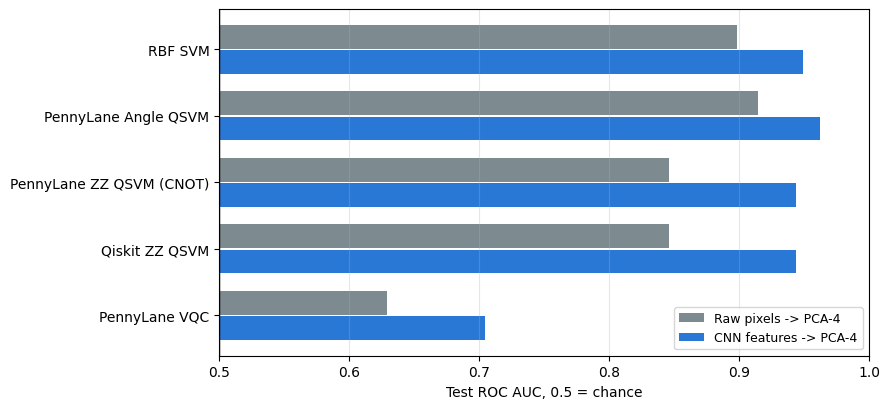

In [35]:
fig, ax = plt.subplots(figsize=(9, 4.2))
y_pos = np.arange(len(order))

ax.barh(y_pos - 0.19, delta["Test raw"], height=0.36, color="#7d8b91", label="Raw pixels -> PCA-4")
ax.barh(y_pos + 0.19, delta["Test CNN"], height=0.36, color="#2a78d6", label="CNN features -> PCA-4")
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlim(0.5, 1.0)
ax.axvline(0.5, color="black", linewidth=1)
ax.set_xlabel("Test ROC AUC, 0.5 = chance")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

## 10. Learned encoding instead of PCA

PCA is unsupervised and fixed before the circuit runs. The alternative is a trainable
`Linear` layer that learns the encoding angles through the circuit, which is supervised
dimensionality reduction rather than a variance-maximising projection. This is an addition,
not a replacement for section 9.

Three variants, each against a control that keeps the front end and deletes the circuit:
`Linear(4 -> 4)` on the raw components, the same on the CNN components, and
`Linear(128 -> 4)` on the whole embedding. The last one fits 516 parameters on 100 images
and is expected to overfit -- it is here because it is the tightly coupled architecture, and
the control tells us whether the circuit adds anything either way.

In [36]:
emb_scaler = MaxAbsScaler().fit(train_cnn_features)

cnn_train_emb = emb_scaler.transform(train_cnn_features)
cnn_val_emb = emb_scaler.transform(val_cnn_features)
cnn_test_emb = emb_scaler.transform(test_cnn_features)

print("Scaled 128-d embedding:", cnn_train_emb.shape,
      " range", round(float(cnn_train_emb.min()), 3), round(float(cnn_train_emb.max()), 3))

Scaled 128-d embedding: (4708, 128)  range 0.0 1.0


In [37]:
class Hybrid(nn.Module):
    def __init__(self, n_in, reps=VQC_REPS):
        super().__init__()
        self.pre = nn.Linear(n_in, nqubits).double()
        self.circ = make_vqc(reps)
        self.theta = nn.Parameter(2 * np.pi * torch.rand((reps + 1) * nqubits, dtype=torch.float64))

    def angles(self, X):
        return torch.tanh(self.pre(X)) * np.pi

    def forward(self, X):
        return self.circ(self.angles(X), self.theta)


class ClassicalControl(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.pre = nn.Linear(n_in, nqubits).double()
        self.out = nn.Linear(nqubits, 1).double()

    def forward(self, X):
        return torch.sigmoid(self.out(torch.tanh(self.pre(X)) * np.pi)).squeeze(-1)


def train_module(cls, x_tr_full, x_va, x_te, init_seed, epochs=60, lr=0.05):
    Xtr = torch.tensor(x_tr_full[train_idx], dtype=torch.float64)
    Xva = torch.tensor(x_va, dtype=torch.float64)
    Xte = torch.tensor(x_te, dtype=torch.float64)
    Y = torch.tensor(y_train_q.astype(np.float64), dtype=torch.float64)

    torch.manual_seed(init_seed)
    model = cls(Xtr.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        opt.zero_grad()
        loss = bce(torch.clamp(model(Xtr), 1e-7, 1 - 1e-7), Y)
        loss.backward()
        opt.step()

    with torch.no_grad():
        out = {"tr": model(Xtr).numpy(), "val": model(Xva).numpy(), "test": model(Xte).numpy()}

    out["loss"] = loss.item()
    out["params"] = sum(p.numel() for p in model.parameters())
    return out


def run_seeds(tag, cls, x_tr_full, x_va, x_te):
    runs = []

    for s in INIT_SEEDS:
        r = train_module(cls, x_tr_full, x_va, x_te, s)
        r["auc"] = roc_auc_score(y_val, r["val"])
        runs.append(r)

    aucs = np.array([r["auc"] for r in runs])
    print(f"{tag:36s} params {runs[0]['params']:4d}   "
          f"val AUC {aucs.mean():.4f} +/- {aucs.std(ddof=1):.4f}", flush=True)
    return runs[int(np.argsort(aucs)[len(aucs) // 2])], aucs

In [38]:
hybrid_inputs = [
    ("raw PCA-4", raw_train_scaled, raw_val_scaled, raw_test_scaled),
    ("CNN PCA-4", cnn_train_scaled, cnn_val_scaled, cnn_test_scaled),
    ("CNN 128-d", cnn_train_emb, cnn_val_emb, cnn_test_emb),
]

hybrid_runs = {}

for tag, tr, va, te in hybrid_inputs:
    hybrid_runs[("Hybrid", tag)] = run_seeds(f"Hybrid, {tag}", Hybrid, tr, va, te)
    hybrid_runs[("Control", tag)] = run_seeds(f"Classical control, {tag}", ClassicalControl, tr, va, te)

Hybrid, raw PCA-4                    params   32   val AUC 0.9604 +/- 0.0036


Classical control, raw PCA-4         params   25   val AUC 0.9625 +/- 0.0006


Hybrid, CNN PCA-4                    params   32   val AUC 0.9959 +/- 0.0002


Classical control, CNN PCA-4         params   25   val AUC 0.9965 +/- 0.0001


Hybrid, CNN 128-d                    params  528   val AUC 0.9929 +/- 0.0026


Classical control, CNN 128-d         params  521   val AUC 0.9969 +/- 0.0000


In [39]:
hybrid_table = pd.DataFrame([
    {"Model": f"{kind} ({tag})",
     "Quantum layer": kind == "Hybrid",
     "Params": best["params"],
     "Val AUC mean": round(float(aucs.mean()), 4),
     "Val AUC sd": round(float(aucs.std(ddof=1)), 4),
     "Test AUC": round(roc_auc_score(y_test, best["test"]), 4),
     "Test bal acc": metrics_at(y_test, best["test"],
                                youden_threshold(y_train_q, best["tr"]))["bal acc"]}
    for (kind, tag), (best, aucs) in hybrid_runs.items()
]).sort_values("Val AUC mean", ascending=False).reset_index(drop=True)

hybrid_table

,Model,Quantum layer,Params,Val AUC mean,Val AUC sd,Test AUC,Test bal acc
0,Control (CNN 128-d),False,521,0.9969,0.0000,0.9598,0.8457
1,Control (CNN PCA-4),False,25,0.9965,0.0001,0.9704,0.9030
2,Hybrid (CNN PCA-4),True,32,0.9959,0.0002,0.9452,0.8521
3,Hybrid (CNN 128-d),True,528,0.9929,0.0026,0.9600,0.9056
4,Control (raw PCA-4),False,25,0.9625,0.0006,0.9126,0.8231
5,Hybrid (raw PCA-4),True,32,0.9604,0.0036,0.9095,0.8282


In [40]:
print("Hybrid minus its own control, validation AUC over 5 initialisations\n")

for tag, _, _, _ in hybrid_inputs:
    h = hybrid_runs[("Hybrid", tag)][1]
    c = hybrid_runs[("Control", tag)][1]
    err = np.sqrt(h.var(ddof=1) / len(h) + c.var(ddof=1) / len(c))
    print(f"  {tag:10s} hybrid {h.mean():.4f}   control {c.mean():.4f}   "
          f"delta {h.mean() - c.mean():+.4f} +/- {err:.4f}")

Hybrid minus its own control, validation AUC over 5 initialisations

  raw PCA-4  hybrid 0.9604   control 0.9625   delta -0.0021 +/- 0.0016
  CNN PCA-4  hybrid 0.9959   control 0.9965   delta -0.0007 +/- 0.0001
  CNN 128-d  hybrid 0.9929   control 0.9969   delta -0.0039 +/- 0.0012


## 11. Summary

Everything below is trained on the same 100 balanced images and scored on the full
524-image validation split (AUC standard error +/-0.029) and the 624-image test split
(+/-0.024). Differences under about 0.05 on test are not interpretable.

### The raw-pixel arm reproduces the original notebook

Rebuilt from scratch here, it lands on the same numbers: RBF SVM 0.9683, Angle QSVM
0.9618, ZZ QSVM 0.9074, VQC 0.7429 validation AUC, and the same test values. The batched
kernel matches the original's nested loop to 0.0, and PennyLane's `CNOT` map still
reproduces Qiskit's `zz_feature_map` at correlation 1.0000000000 on both representations.
The comparison is therefore between two arms of one run, not between two notebooks.

### CNN features help every model

The extractor is small and trains fast -- best validation AUC 0.9969 at epoch 6, 37
seconds -- and every downstream model improves on test: RBF SVM +0.051, Angle QSVM +0.048,
ZZ QSVM +0.098, VQC +0.076. Only the ZZ and VQC gains clearly clear the +/-0.048 noise
floor, but all five point the same way.

The mechanism is visible in the PCA. On raw pixels four components carry 59.8% of the
variance; on the CNN embedding the first component alone carries 90.1% and four carry
97.4%. Passing 4 numbers to the qubits throws away almost half the raw-pixel signal and
almost none of the learned one.

### The quantum models still do not beat the classical control

On CNN features the Angle QSVM leads at 0.9963 validation and 0.9623 test, against the RBF
SVM's 0.9935 and 0.9495. Those gaps are +0.003 and +0.013, both well inside one standard
error, and the RBF SVM has the better test balanced accuracy of the two (0.8962 against
0.8487). The ZZ QSVM is worse still on that measure -- 0.9435 test AUC but 0.7799 balanced
accuracy, meaning its frozen threshold transfers badly even though its ranking is good.

So the ordering from the original notebook survives the change of representation. Better
features moved every model up; they did not move the quantum models past the classical one.

### The quantum layer contributes nothing in the hybrids

This is the sharper test, because the hybrid and its control share a front end exactly and
differ only by the circuit. All three deltas are negative: -0.0021 on raw PCA-4, -0.0007 on
CNN PCA-4, -0.0039 on the CNN 128-d embedding, each about as large as its own standard
error. The single best validation AUC in the whole notebook, 0.9969, belongs to the
classical control on the 128-d embedding, with no circuit in it at all.

### The VQC was encoder-limited, but it is still last

Its validation AUC moves further than anything else, 0.7429 to 0.9583. On test it only
reaches 0.7049, and it remains the weakest of the five models in both arms. The jump says
the fixed 4-component pixel encoding was a real bottleneck for it; it does not say the
circuit became competitive.

### Where the gain actually comes from

The end-to-end CNN scores 0.9599 test AUC on its own. The 25-parameter classical control
reading its features gets 0.9704, and the best quantum model gets 0.9623. Everything in the
CNN arm sits at roughly the level of the feature extractor that fed it, which is what it
looks like when the representation is doing the work and the classifier on top is close to
irrelevant.

### Limitations

The CNN is trained on 4,708 labels while PCA on pixels sees none, so part of the CNN arm's
advantage is supervision rather than depth, and this design cannot separate them.

The CNN checkpoint was selected on validation AUC, and the downstream models are then
scored on that same split. The CNN arm's validation numbers are therefore optimistic in a
way the raw arm's are not. The test split is clean for both, which is why the conclusions
above lean on test.


## Saving results

Written under a `cnn_` prefix so the original notebook's outputs are untouched.

In [41]:
import os

os.makedirs("results", exist_ok=True)

comparison.to_csv("results/cnn_features_comparison.csv", index=False)
validation.to_csv("results/cnn_features_validation.csv", index=False)
test.to_csv("results/cnn_features_test.csv", index=False)
delta.to_csv("results/cnn_features_delta.csv")
hybrid_table.to_csv("results/cnn_features_hybrids.csv", index=False)
hist.to_csv("results/cnn_training_history.csv", index=False)
torch.save(cnn.state_dict(), "results/cnn_feature_extractor.pt")
np.savez("results/cnn_features_scores.npz",
         y_val=y_val, y_test=y_test,
         **{f"val__{k}": v for k, v in val_scores.items()},
         **{f"test__{k}": v for k, v in test_scores.items()})

print("\n".join(sorted(f for f in os.listdir("results") if f.startswith("cnn_"))))

cnn_feature_extractor.pt
cnn_features_comparison.csv
cnn_features_delta.csv
cnn_features_hybrids.csv
cnn_features_scores.npz
cnn_features_test.csv
cnn_features_validation.csv
cnn_training_history.csv
